In [1]:
# ==============================================================================
# FASE 0: IMPORTACIONES Y CONFIGURACIÓN INICIAL
# ==============================================================================

# 1. Librerías Estándar de Python
import os
import re

# 2. Manipulación y Análisis de Datos
import numpy as np
import pandas as pd

# 3. Visualización Estática
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# 4. Visualización Geoespacial (Mapas)
import folium
from folium.plugins import HeatMap, Fullscreen
from branca.element import Template, MacroElement

# 5. Machine Learning (Scikit-Learn)
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report





# Configuración de rutas
ruta_base = r"C:\Users\Free2\Desktop\Proyecto_Localia_Rendimiento\Datos"
ruta_estandarizada = os.path.join(ruta_base, "Datos_Estandarizados")
ruta_finanzas = os.path.join(ruta_base, "4_Finanzas")
ruta_hinchada = os.path.join(ruta_base, "2_Hinchada", "Popularidad")

In [2]:
# ==============================================================================
# FASE 1: INGESTA Y ESTANDARIZACIÓN DE DATOS
# ==============================================================================

# Carga de datasets
df_partidos = pd.read_csv(os.path.join(ruta_estandarizada, 'dataset_modelo_localia_estandarizado.csv'))
df_valor = pd.read_csv(os.path.join(ruta_finanzas, 'Valor_Plantel', 'plantillas_valor_estandarizado.csv'))
df_socios = pd.read_csv(os.path.join(ruta_estandarizada, 'socios_historico_estandarizado_unificado.csv'))
df_estadios = pd.read_csv(os.path.join(ruta_estandarizada, 'estadios_estandarizado_unificado.csv'))
df_redes = pd.read_csv(os.path.join(ruta_hinchada, 'Engagement_Redes', 'redes_historico_estandarizado.csv'))
df_pop = pd.read_csv(os.path.join(ruta_hinchada, 'Encuestas', 'popularidad_clubes_unificado_estandarizado.csv'))
df_ingresos_raw = pd.read_csv(os.path.join(ruta_finanzas, 'Ingresos_Clubes', 'finanzas_clubes_estandarizado_unificado.csv'))

# Normalización de columnas
for df in [df_partidos, df_valor, df_socios, df_estadios, df_redes, df_pop, df_ingresos_raw]:
    df.columns = df.columns.str.strip()

df_redes = df_redes.rename(columns={'Total_Seguidores': 'Redes'})
df_pop = df_pop.rename(columns={'Porcentaje_Consultoras': 'Popularidad'})
df_partidos = df_partidos.rename(columns={'Home': 'Local', 'Away': 'Visitante'})

for df in [df_partidos, df_valor, df_socios, df_redes]:
    if 'Temporada' in df.columns:
        df['Temporada'] = df['Temporada'].astype(str).str.extract(r'(\d{4})')[0]

In [3]:
# ==============================================================================
# FASE 2: CONSOLIDACIÓN DEL DATASET MASTER
# ==============================================================================

def enriquecer_equipo(df_base, prefijo):
    col_eq = 'Local' if prefijo == 'L' else 'Visitante'
    
    # Merge de variables financieras y sociales
    df_base = pd.merge(df_base, df_valor[['Temporada', 'Club', 'Valor_Plantel_Millones_EUR']], 
                       left_on=['Temporada', col_eq], right_on=['Temporada', 'Club'], how='left').drop(columns=['Club']).rename(columns={'Valor_Plantel_Millones_EUR': f'{prefijo}_Valor'})
    df_base = pd.merge(df_base, df_socios[['Temporada', 'Club', 'Cantidad_Socios']], 
                       left_on=['Temporada', col_eq], right_on=['Temporada', 'Club'], how='left').drop(columns=['Club']).rename(columns={'Cantidad_Socios': f'{prefijo}_Socios'})
    df_base = pd.merge(df_base, df_redes[['Temporada', 'Club', 'Redes']], 
                       left_on=['Temporada', col_eq], right_on=['Temporada', 'Club'], how='left').drop(columns=['Club']).rename(columns={'Redes': f'{prefijo}_Redes'})
    df_base = pd.merge(df_base, df_pop[['Club', 'Popularidad']], 
                       left_on=[col_eq], right_on=['Club'], how='left').drop(columns=['Club']).rename(columns={'Popularidad': f'{prefijo}_Pop'})
    
    anio_max = df_ingresos_raw['Anio'].max()
    df_ing = df_ingresos_raw[df_ingresos_raw['Anio'] == anio_max].rename(columns={'Valor_ARS': 'Ingresos'})
    df_base = pd.merge(df_base, df_ing[['Club', 'Ingresos']], 
                       left_on=[col_eq], right_on=['Club'], how='left').drop(columns=['Club']).rename(columns={'Ingresos': f'{prefijo}_Ingresos'})
    return df_base

# Aplicación del cruce espejado
df_master = enriquecer_equipo(df_partidos, 'L')
df_master = enriquecer_equipo(df_master, 'V')

# Integración de datos de infraestructura
df_master = pd.merge(df_master, 
                     df_estadios[['Club', 'Capacidad_Wiki', 'valor_m2_usd', 'Coordenadas_GPS', 'Anio_Inauguracion']], 
                     left_on='Local', right_on='Club', how='left').drop(columns=['Club'])

In [4]:
# ==============================================================================
# FASE 2: CONSOLIDACIÓN DEL DATASET MASTER
# ==============================================================================

def enriquecer_equipo(df_base, prefijo):
    col_eq = 'Local' if prefijo == 'L' else 'Visitante'
    
    # Merge de variables financieras y sociales
    df_base = pd.merge(df_base, df_valor[['Temporada', 'Club', 'Valor_Plantel_Millones_EUR']], 
                       left_on=['Temporada', col_eq], right_on=['Temporada', 'Club'], how='left').drop(columns=['Club']).rename(columns={'Valor_Plantel_Millones_EUR': f'{prefijo}_Valor'})
    df_base = pd.merge(df_base, df_socios[['Temporada', 'Club', 'Cantidad_Socios']], 
                       left_on=['Temporada', col_eq], right_on=['Temporada', 'Club'], how='left').drop(columns=['Club']).rename(columns={'Cantidad_Socios': f'{prefijo}_Socios'})
    df_base = pd.merge(df_base, df_redes[['Temporada', 'Club', 'Redes']], 
                       left_on=['Temporada', col_eq], right_on=['Temporada', 'Club'], how='left').drop(columns=['Club']).rename(columns={'Redes': f'{prefijo}_Redes'})
    df_base = pd.merge(df_base, df_pop[['Club', 'Popularidad']], 
                       left_on=[col_eq], right_on=['Club'], how='left').drop(columns=['Club']).rename(columns={'Popularidad': f'{prefijo}_Pop'})
    
    anio_max = df_ingresos_raw['Anio'].max()
    df_ing = df_ingresos_raw[df_ingresos_raw['Anio'] == anio_max].rename(columns={'Valor_ARS': 'Ingresos'})
    df_base = pd.merge(df_base, df_ing[['Club', 'Ingresos']], 
                       left_on=[col_eq], right_on=['Club'], how='left').drop(columns=['Club']).rename(columns={'Ingresos': f'{prefijo}_Ingresos'})
    return df_base

# Aplicación del cruce espejado
df_master = enriquecer_equipo(df_partidos, 'L')
df_master = enriquecer_equipo(df_master, 'V')

# Integración de datos de infraestructura
df_master = pd.merge(df_master, 
                     df_estadios[['Club', 'Capacidad_Wiki', 'valor_m2_usd', 'Coordenadas_GPS', 'Anio_Inauguracion']], 
                     left_on='Local', right_on='Club', how='left').drop(columns=['Club'])

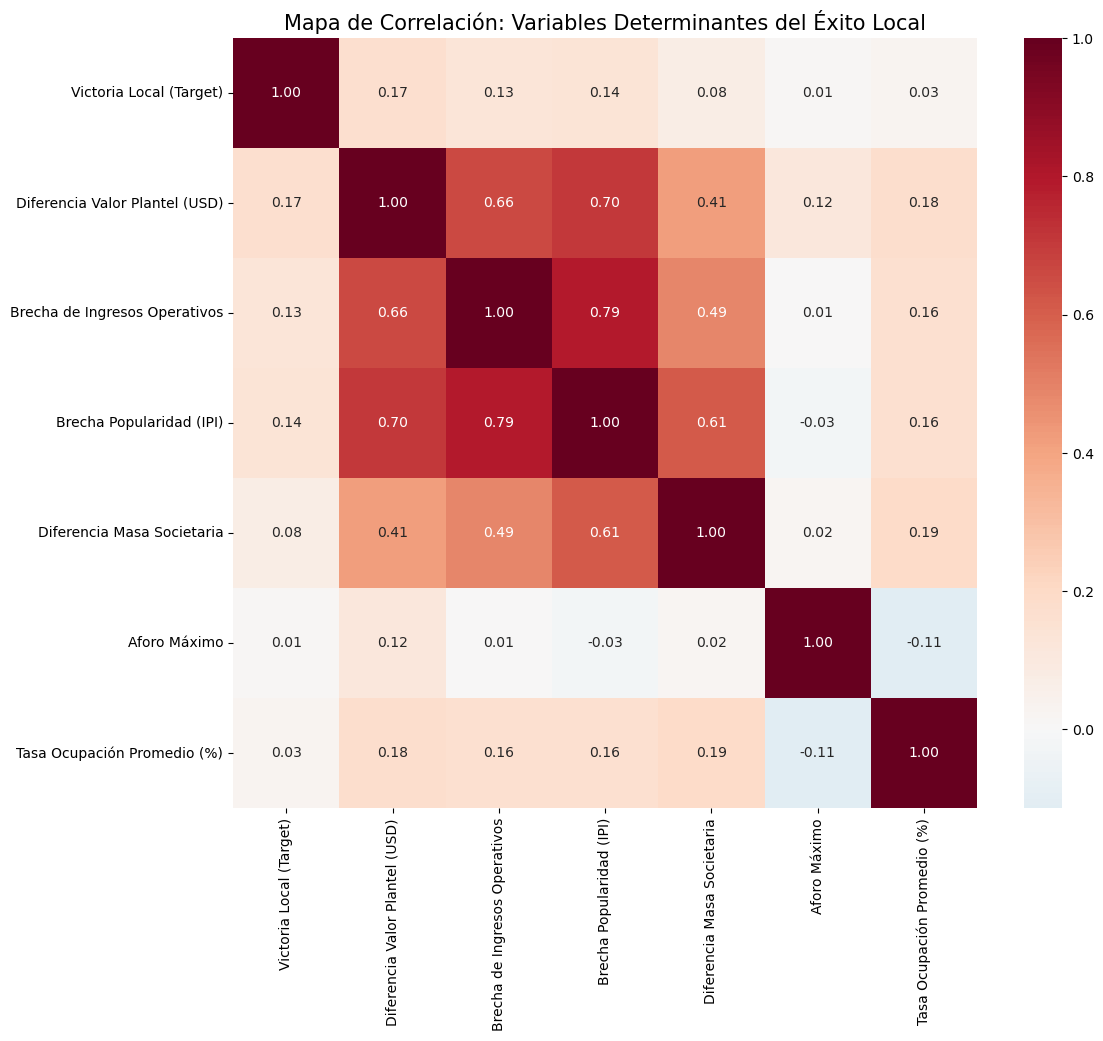

In [5]:
# ==============================================================================
# FASE 3: FEATURE ENGINEERING E ÍNDICES DE NEGOCIO
# ==============================================================================

# Creación del Índice de Popularidad Integral (IPI)
scaler = MinMaxScaler()
for p in ['L', 'V']:
    df_master[f'{p}_Pop_Norm'] = scaler.fit_transform(df_master[[f'{p}_Pop']].fillna(0))
    df_master[f'{p}_Redes_Norm'] = scaler.fit_transform(df_master[[f'{p}_Redes']].fillna(0))
    df_master[f'{p}_IPI'] = (df_master[f'{p}_Pop_Norm'] * 0.6) + (df_master[f'{p}_Redes_Norm'] * 0.4)

# Creación de variables relativas e indicadores de ocupación
df_master['Relacion_Capacidad_Asistencia'] = (df_master['L_Socios'] / df_master['Capacidad_Wiki']).clip(0, 1.2)
df_master['Dif_Valor_Plantel'] = df_master['L_Valor'] - df_master['V_Valor']
df_master['Dif_Ingresos'] = df_master['L_Ingresos'] - df_master['V_Ingresos']
df_master['Dif_Popularidad_IPI'] = df_master['L_IPI'] - df_master['V_IPI']
df_master['Dif_Socios'] = df_master['L_Socios'] - df_master['V_Socios']
df_master['Capacidad_Estadio'] = df_master['Capacidad_Wiki']

# Definición del Target
df_master['Victoria_Local'] = (df_master['Goles_Local'] > df_master['Goles_Visitante']).astype(int)
df_final = df_master.fillna(0)

vars_maestras = ['Dif_Valor_Plantel', 'Dif_Ingresos', 'Dif_Popularidad_IPI', 'Dif_Socios', 'Capacidad_Wiki', 'Relacion_Capacidad_Asistencia']

# Renombramiento de variables para presentación ejecutiva
etiquetas_ejecutivas = {
    'Victoria_Local': 'Victoria Local (Target)',
    'Dif_Valor_Plantel': 'Diferencia Valor Plantel (USD)',
    'Dif_Ingresos': 'Brecha de Ingresos Operativos',
    'Dif_Popularidad_IPI': 'Brecha Popularidad (IPI)',
    'Dif_Socios': 'Diferencia Masa Societaria',
    'Capacidad_Wiki': 'Aforo Máximo',
    'Relacion_Capacidad_Asistencia': 'Tasa Ocupación Promedio (%)'
}

df_heatmap = df_final[['Victoria_Local'] + vars_maestras].rename(columns=etiquetas_ejecutivas)

# Mapa de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(df_heatmap.corr(), annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Mapa de Correlación: Variables Determinantes del Éxito Local', fontsize=15)
plt.show()

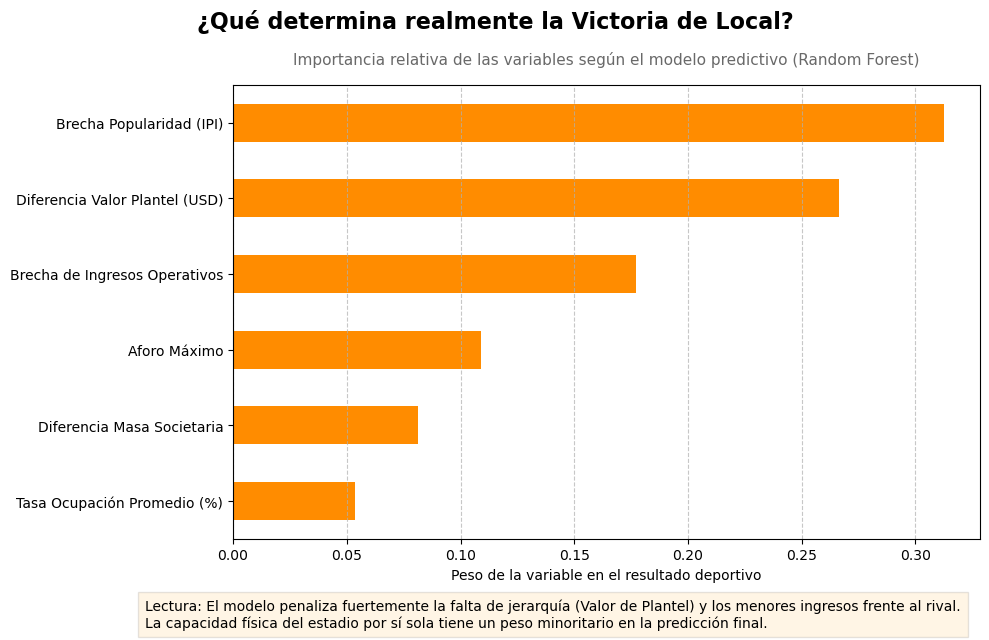

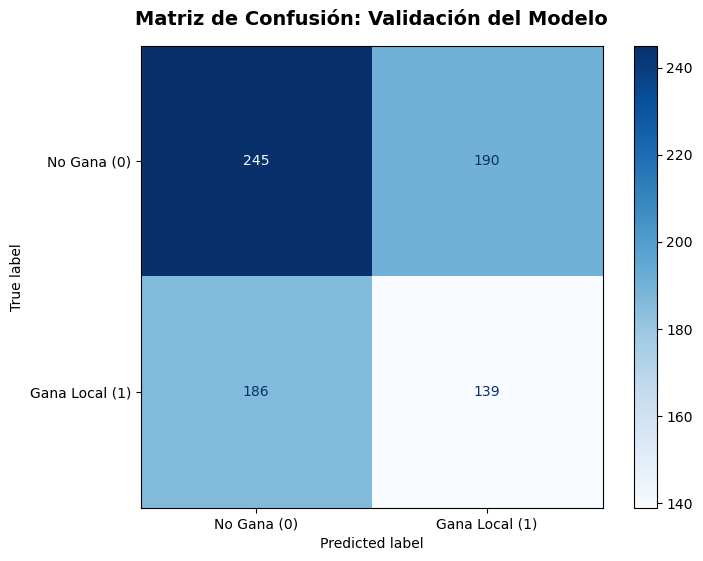

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.57      0.56      0.57       435
           1       0.42      0.43      0.43       325

    accuracy                           0.51       760
   macro avg       0.50      0.50      0.50       760
weighted avg       0.51      0.51      0.51       760



In [6]:
# ==============================================================================
# FASE 4: MODELADO PREDICTIVO (RANDOM FOREST)
# ==============================================================================

# 1. Definición de matrices (X = predictoras, y = target) y Split
X = df_final[vars_maestras]
y = df_final['Victoria_Local']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenamiento del modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Gráfico de Importancia de Variables (Data Storytelling)
# Renombramiento de variables para presentación ejecutiva
etiquetas_ejecutivas = {
    'Dif_Valor_Plantel': 'Diferencia Valor Plantel (USD)',
    'Dif_Ingresos': 'Brecha de Ingresos Operativos',
    'Dif_Popularidad_IPI': 'Brecha Popularidad (IPI)',
    'Dif_Socios': 'Diferencia Masa Societaria',
    'Capacidad_Wiki': 'Aforo Máximo',
    'Relacion_Capacidad_Asistencia': 'Tasa Ocupación Promedio (%)'
}

importancias = pd.Series(model.feature_importances_, index=vars_maestras)
importancias = importancias.rename(index=etiquetas_ejecutivas).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='darkorange')

plt.suptitle('¿Qué determina realmente la Victoria de Local?', fontsize=16, fontweight='bold', y=0.98)
plt.title('Importancia relativa de las variables según el modelo predictivo (Random Forest)', fontsize=11, color='dimgray', pad=15)

plt.xlabel('Peso de la variable en el resultado deportivo', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

nota = "Lectura: El modelo penaliza fuertemente la falta de jerarquía (Valor de Plantel) y los menores ingresos frente al rival.\nLa capacidad física del estadio por sí sola tiene un peso minoritario en la predicción final."
plt.figtext(0.15, -0.05, nota, ha="left", fontsize=10, bbox={"facecolor":"orange", "alpha":0.1, "pad":5})

plt.tight_layout()
plt.show()

# 4. Evaluación del Modelo (Matriz de Confusión)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Gana (0)', 'Gana Local (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Matriz de Confusión: Validación del Modelo', fontsize=14, fontweight='bold', pad=15)
plt.show()

# 5. Reporte de Métricas Finales
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

📝 Nota Analítica sobre el Rendimiento del Modelo:
Un Accuracy del 51% es el comportamiento esperado en modelos de Sports Analytics basados en macro-variables (fuera de la cancha). El fútbol es un sistema de alta varianza estocástica a corto plazo. Este modelo confirma que el presupuesto y la infraestructura no son una "bola de cristal" para un partido aislado, sino factores que alteran la probabilidad base. Por este motivo, para evaluar el Costo de Oportunidad de la infraestructura, no debemos mirar la predicción de un partido individual, sino la agregación de probabilidades a lo largo de una temporada mediante Simulaciones de Montecarlo (Fase 7).

In [7]:
# ==============================================================================
# FASE 5: MODELADO DE INGRESOS Y COSTO DE OPORTUNIDAD
# ==============================================================================

# Proyección de ingresos (Contexto 2025/26)
ingreso_anual_2026 = 115000000000 
ingreso_matchday_hoy = ingreso_anual_2026 * 0.35 

model_money = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, df_final['L_Ingresos'])

# Simulación de modernización de infraestructura (Capacidad 100k)
boca_base = X[df_final['Local'] == 'Boca Juniors'].iloc[-1:].copy()
pred_base = model_money.predict(boca_base)[0]

boca_proy = boca_base.copy()
boca_proy['Capacidad_Wiki'] = 100000
boca_proy['Relacion_Capacidad_Asistencia'] = 0.98
pred_futura = model_money.predict(boca_proy)[0]

# Cálculo de rentabilidad
multiplicador_capacidad = pred_futura / pred_base
ingreso_proyectado_real = ingreso_matchday_hoy * multiplicador_capacidad
ganancia_extra = ingreso_proyectado_real - ingreso_matchday_hoy

print("--- PROYECCIÓN ESTRATÉGICA: NUEVA INFRAESTRUCTURA ---")
print(f"Ingreso Matchday Actual: ${ingreso_matchday_hoy:,.0f} ARS")
print(f"Ingreso Proyectado (100k): ${ingreso_proyectado_real:,.0f} ARS")
print(f"Ganancia Extra Anual: ${ganancia_extra:,.0f} ARS")
print(f"Incremento de facturación: {((multiplicador_capacidad - 1) * 100):.1f}%")

--- PROYECCIÓN ESTRATÉGICA: NUEVA INFRAESTRUCTURA ---
Ingreso Matchday Actual: $40,250,000,000 ARS
Ingreso Proyectado (100k): $60,455,233,008 ARS
Ganancia Extra Anual: $20,205,233,008 ARS
Incremento de facturación: 50.2%


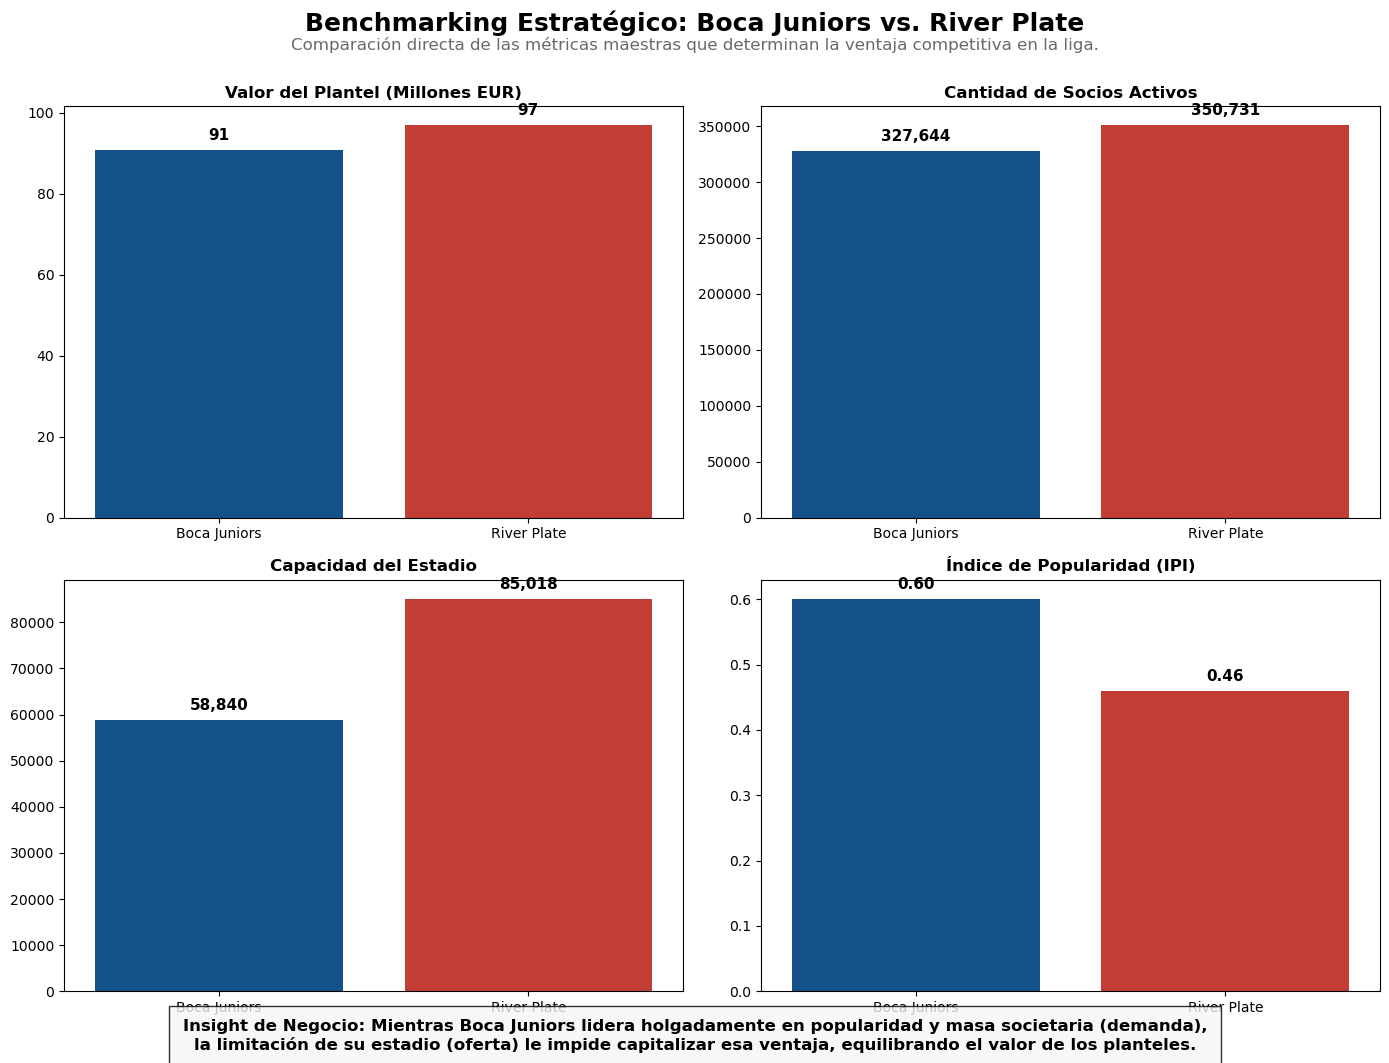

In [8]:
# ==============================================================================
# FASE 5.5: BENCHMARKING COMPETITIVO (BOCA JUNIORS VS. RIVER PLATE)
# ==============================================================================


clubes_benchmark = ['Boca Juniors', 'River Plate']
df_bench = df_final[df_final['Local'].isin(clubes_benchmark)].replace(0, np.nan).groupby('Local').last().reset_index()

metricas = ['L_Valor', 'L_Socios', 'Capacidad_Estadio', 'L_IPI']
titulos_metricas = ['Valor del Plantel (Millones EUR)', 'Cantidad de Socios Activos', 
                    'Capacidad del Estadio', 'Índice de Popularidad (IPI)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Título principal y subtítulo
fig.suptitle('Benchmarking Estratégico: Boca Juniors vs. River Plate', fontsize=18, fontweight='bold', y=1.02)
plt.figtext(0.5, 0.98, 'Comparación directa de las métricas maestras que determinan la ventaja competitiva en la liga.', ha='center', fontsize=12, color='dimgray')

colores = {'Boca Juniors': '#00529F', 'River Plate': '#DA291C'}

for i, (metrica, titulo) in enumerate(zip(metricas, titulos_metricas)):
    fila = i // 2
    col = i % 2
    ax = axes[fila, col]
    
    sns.barplot(data=df_bench, x='Local', y=metrica, hue='Local', palette=colores, ax=ax, legend=False)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    for p in ax.patches:
        valor = p.get_height()
        if pd.isna(valor): valor = 0 
        formato = f"{valor:,.0f}" if metrica != 'L_IPI' else f"{valor:.2f}"
        ax.annotate(formato, (p.get_x() + p.get_width() / 2., valor), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Conclusión de negocio en el gráfico
conclusion = "Insight de Negocio: Mientras Boca Juniors lidera holgadamente en popularidad y masa societaria (demanda),\nla limitación de su estadio (oferta) le impide capitalizar esa ventaja, equilibrando el valor de los planteles."
plt.figtext(0.5, -0.02, conclusion, ha='center', fontsize=12, fontweight='bold', bbox={"facecolor":"whitesmoke", "alpha":0.8, "pad":10})

plt.tight_layout()
plt.show()

In [9]:
# ==============================================================================
# FASE 6: ANÁLISIS GEOESPACIAL DE INFRAESTRUCTURA ("BILLETERA MATA BARRIO")
# ==============================================================================


# 1. Función de limpieza de GPS
def limpiar_gps(val):
    if pd.isna(val) or val == 0: return None, None
    try:
        numeros = re.findall(r"[-+]?\d+\.\d+", str(val))
        if len(numeros) >= 2:
            return float(numeros[0]), float(numeros[1])
    except:
        return None, None
    return None, None

# 2. Preparar datos geoespaciales (sumamos L_Valor para mostrar en el mapa)
geo_analisis = df_final[df_final['valor_m2_usd'] > 0].groupby('Local').agg({
    'Victoria_Local': 'mean',
    'valor_m2_usd': 'first',
    'Coordenadas_GPS': 'first',
    'Capacidad_Estadio': 'first',
    'L_Valor': 'first' 
}).reset_index()

geo_analisis[['Lat', 'Lon']] = geo_analisis['Coordenadas_GPS'].apply(lambda x: pd.Series(limpiar_gps(x)))
geo_analisis = geo_analisis.dropna(subset=['Lat', 'Lon'])

# 3. Crear Mapa Base Centrado en CABA/GBA
m = folium.Map(location=[-34.6037, -58.3816], zoom_start=11, tiles='cartodbpositron')
Fullscreen(position='topright').add_to(m)

# 4. Capa de Calor (Densidad de Victorias)
heat_data = [[row['Lat'], row['Lon'], row['Victoria_Local']] for _, row in geo_analisis.iterrows()]
HeatMap(heat_data, name="Densidad de Victorias (Calor)", radius=25, blur=15, max_zoom=1).add_to(m)

# 5. Marcadores de Clubes (Con diseño de tarjeta de negocio en el popup)
for _, row in geo_analisis.iterrows():
    # Lógica de color socioeconómico
    if row['valor_m2_usd'] > 2200:
        color_node, cat_barrio = 'darkred', 'Top / Residencial Alta'
    elif row['valor_m2_usd'] > 1500:
        color_node, cat_barrio = 'orange', 'Clase Media / Comercial'
    else:
        color_node, cat_barrio = 'cadetblue', 'Popular / Desarrollo'
        
    # Destaque especial para Boca y River
    es_superclasico = row['Local'] in ['Boca Juniors', 'River Plate']
    borde_color = 'black' if es_superclasico else color_node
    grosor_borde = 3 if es_superclasico else 1

    # HTML del Popup (Mini Dashboard)
    html_popup = f"""
    <div style="width:220px; font-family:Arial, sans-serif;">
        <h4 style="margin-bottom:5px; color:{color_node};"><b>{row['Local']}</b></h4>
        <hr style="margin:2px 0;">
        <b>Win Rate (Local):</b> {row['Victoria_Local']:.1%}<br>
        <b>Plantel:</b> €{row['L_Valor']:.1f}M<br>
        <b>Aforo:</b> {row['Capacidad_Estadio']:,}<br>
        <hr style="margin:2px 0;">
        <i style="font-size:11px; color:gray;">Barrio: {cat_barrio}<br>Valor Suelo: USD {row['valor_m2_usd']:.0f}/m²</i>
    </div>
    """
    
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=row['Victoria_Local'] * 35, # Escala visual del éxito
        popup=folium.Popup(html_popup, max_width=300),
        tooltip=f"Clic para ver métricas de {row['Local']}",
        color=borde_color,
        weight=grosor_borde,
        fill=True,
        fill_color=color_node,
        fill_opacity=0.7
    ).add_to(m)

# 6. LEYENDA TÉCNICA (Diseño Corporativo)
template = """
{% macro html(this, kwargs) %}
<div style='position: fixed; 
            bottom: 30px; left: 30px; width: 330px; 
            background-color: rgba(255, 255, 255, 0.95); border: 1px solid #ddd; 
            border-radius: 8px; z-index:9999; font-size:13px; font-family:Arial;
            padding: 15px; box-shadow: 2px 2px 10px rgba(0,0,0,0.15);'>
    <h4 style='margin-top:0; margin-bottom:10px; color:#333;'>🗺️ Contexto Geo-Económico</h4>
    <b>Clúster Inmobiliario (USD/m²):</b><br>
    <i class='fa fa-circle' style='color:darkred; margin-top:5px;'></i> > 2200 USD (Alto)<br>
    <i class='fa fa-circle' style='color:orange; margin-top:5px;'></i> 1500 - 2200 USD (Medio)<br>
    <i class='fa fa-circle' style='color:cadetblue; margin-top:5px;'></i> < 1500 USD (Popular)<br><br>
    
    <b>Tamaño del Círculo:</b> Representa el <b>Win Rate</b> local.<br><br>
    
    <div style='background-color:#f4f6f9; padding:10px; border-left:4px solid #00529F; border-radius:4px;'>
        <b>💡 Insight de Negocio:</b><br>
        El éxito deportivo (círculos grandes) se da en todas las zonas. 
        El barrio o la mística no dictan el resultado, el presupuesto (billetera) sí.
    </div>
</div>
{% endmacro %}
"""

macro = MacroElement()
macro._template = Template(template)
m.get_root().add_child(macro)

folium.LayerControl().add_to(m)
display(m)

⚠️ Data Caveat (Sesgo de Selección):
La variable valor_m2_usd extraída mediante Web Scraping de portales formales presenta limitaciones de representatividad en zonas de alta disparidad. Por ejemplo, el indicador sobreestima el valor del entorno socioeconómico de Defensa y Justicia al no registrar las viviendas informales adyacentes al estadio, generando una anomalía estadística al compararlo con zonas de urbanización más homogénea como Avellaneda. En modelos productivos, esto requeriría un tratamiento de outliers o la inclusión de variables censales.

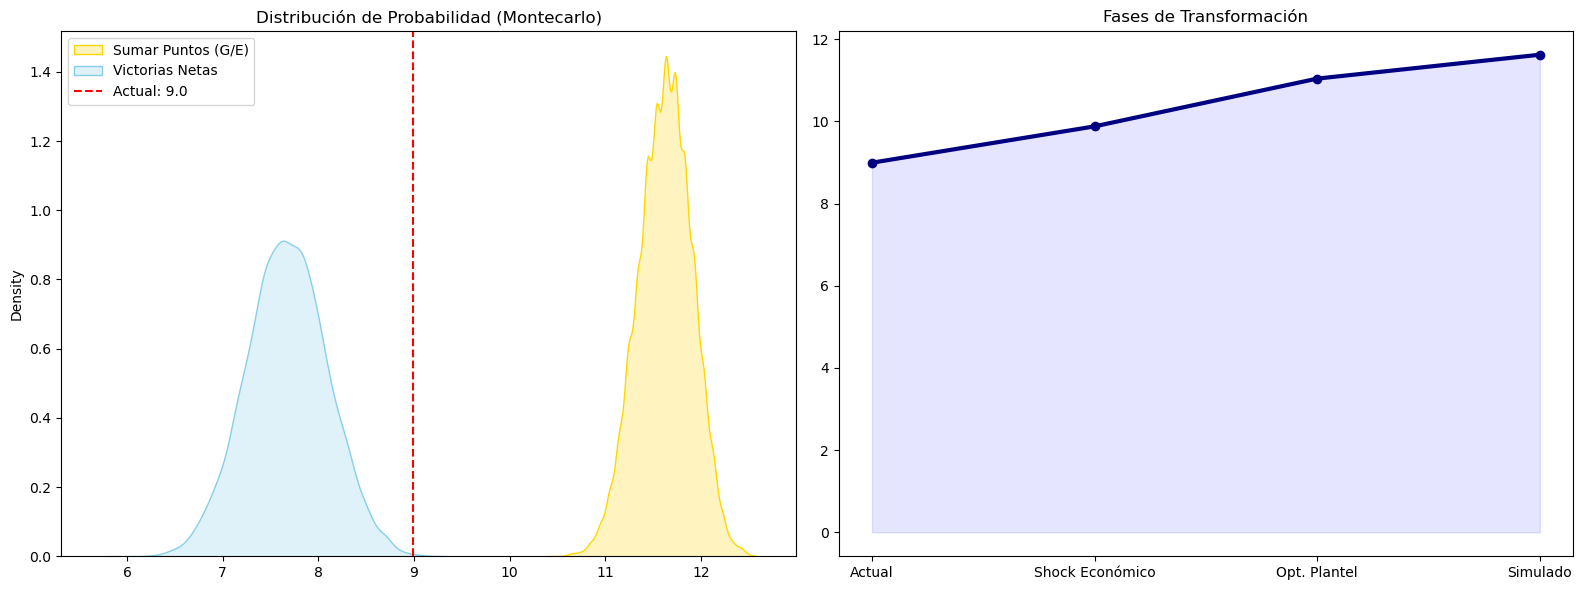

--- RESULTADOS SIMULACIÓN MONTECARLO ---
Expectativa de sumar puntos: 11.6 de 13
Mejora proyectada vs. Actual: 29.2%


In [10]:
# ==============================================================================
# FASE 7: SIMULACIÓN ACTUARIAL (MONTECARLO)
# ==============================================================================

# Simulación Montecarlo de shock económico
n_simulaciones = 10000
partidos_vis_temp = 13 
partidos_boca_vis = df_final[df_final['Visitante'] == 'Boca Juniors'].copy()

eficiencia_capital = 0.50  
umbral_victoria_vis = 0.68 

resultados_puntos, resultados_victorias = [], []

for _ in range(n_simulaciones):
    X_mc = partidos_boca_vis[vars_maestras].copy()
    
    # Modelado de saturación (Log-Scaling) y ruido estocástico
    log_ingresos = np.log1p(partidos_boca_vis['V_Ingresos'] * eficiencia_capital)
    X_mc['Dif_Ingresos'] = X_mc['Dif_Ingresos'] - log_ingresos
    X_mc['Dif_Valor_Plantel'] = X_mc['Dif_Valor_Plantel'] - (partidos_boca_vis['V_Valor'] * 0.20)
    
    ruido = np.random.normal(1, 0.25, size=len(X_mc))
    X_mc = X_mc.multiply(ruido, axis=0)
    
    probs_no_perder = model.predict_proba(X_mc)[:, 0]
    resultados_puntos.append(((probs_no_perder > 0.5).sum() / len(X_mc)) * partidos_vis_temp)
    resultados_victorias.append(((probs_no_perder > umbral_victoria_vis).sum() / len(X_mc)) * partidos_vis_temp)

# Visualización de la simulación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(resultados_puntos, fill=True, color='gold', label='Sumar Puntos (G/E)', ax=ax1)
sns.kdeplot(resultados_victorias, fill=True, color='skyblue', label='Victorias Netas', ax=ax1)
puntos_actuales = ((model.predict(partidos_boca_vis[vars_maestras]) == 0).sum() / len(partidos_boca_vis)) * partidos_vis_temp
ax1.axvline(puntos_actuales, color='red', linestyle='--', label=f'Actual: {puntos_actuales:.1f}')
ax1.set_title('Distribución de Probabilidad (Montecarlo)')
ax1.legend()

fases = ['Actual', 'Shock Económico', 'Opt. Plantel', 'Simulado']
valores = [puntos_actuales, np.mean(resultados_puntos) * 0.85, np.mean(resultados_puntos) * 0.95, np.mean(resultados_puntos)]
ax2.plot(fases, valores, marker='o', linestyle='-', color='navy', linewidth=3)
ax2.fill_between(fases, valores, color='blue', alpha=0.1)
ax2.set_title('Fases de Transformación')
plt.tight_layout()
plt.show()

print("--- RESULTADOS SIMULACIÓN MONTECARLO ---")
print(f"Expectativa de sumar puntos: {np.mean(resultados_puntos):.1f} de 13")
print(f"Mejora proyectada vs. Actual: {((np.mean(resultados_puntos)/puntos_actuales)-1)*100:.1f}%")

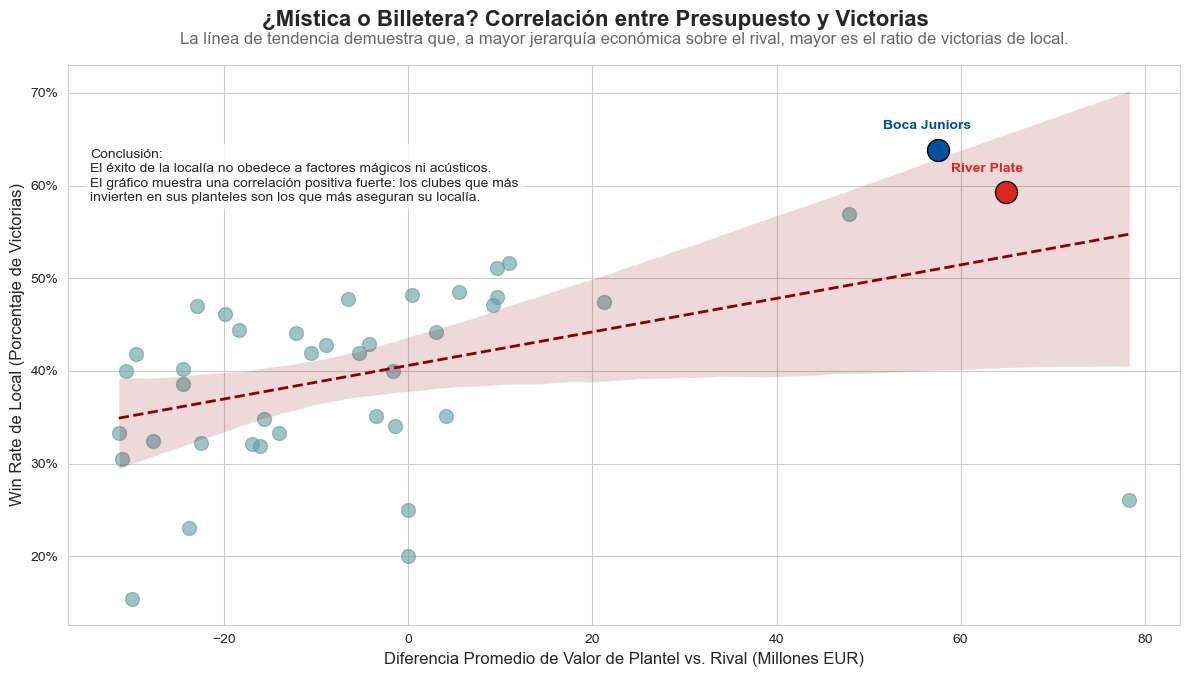

In [11]:
# ==============================================================================
# FASE 8: VISUALIZACIÓN DE NEGOCIO 1 - "BILLETERA MATA BARRIO"
# ==============================================================================


df_scatter = df_final.groupby('Local').agg(
    Win_Rate=('Victoria_Local', 'mean'),
    Dif_Valor_Promedio=('Dif_Valor_Plantel', 'mean')
).reset_index()

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.regplot(data=df_scatter, x='Dif_Valor_Promedio', y='Win_Rate', 
                 scatter_kws={'s': 100, 'alpha': 0.6, 'color': 'cadetblue'}, 
                 line_kws={'color': 'darkred', 'linewidth': 2, 'linestyle': '--'})

boca_punto = df_scatter[df_scatter['Local'] == 'Boca Juniors']
river_punto = df_scatter[df_scatter['Local'] == 'River Plate']

if not boca_punto.empty and not river_punto.empty:
    plt.scatter(boca_punto['Dif_Valor_Promedio'], boca_punto['Win_Rate'], color='#00529F', s=250, edgecolor='black', zorder=5)
    plt.scatter(river_punto['Dif_Valor_Promedio'], river_punto['Win_Rate'], color='#DA291C', s=250, edgecolor='black', zorder=5)

    plt.annotate('Boca Juniors', (boca_punto['Dif_Valor_Promedio'].values[0], boca_punto['Win_Rate'].values[0]), xytext=(-40, 15), textcoords='offset points', fontweight='bold', color='#00529F')
    plt.annotate('River Plate', (river_punto['Dif_Valor_Promedio'].values[0], river_punto['Win_Rate'].values[0]), xytext=(-40, 15), textcoords='offset points', fontweight='bold', color='#DA291C')

# Títulos descriptivos
plt.suptitle('¿Mística o Billetera? Correlación entre Presupuesto y Victorias', fontsize=16, fontweight='bold', y=0.96)
plt.title('La línea de tendencia demuestra que, a mayor jerarquía económica sobre el rival, mayor es el ratio de victorias de local.', fontsize=12, color='dimgray', pad=15)

plt.xlabel('Diferencia Promedio de Valor de Plantel vs. Rival (Millones EUR)', fontsize=12)
plt.ylabel('Win Rate de Local (Porcentaje de Victorias)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

# Cuadro explicativo
texto_cuadro = "Conclusión:\nEl éxito de la localía no obedece a factores mágicos ni acústicos.\nEl gráfico muestra una correlación positiva fuerte: los clubes que más\ninvierten en sus planteles son los que más aseguran su localía."
plt.text(0.02, 0.85, texto_cuadro, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

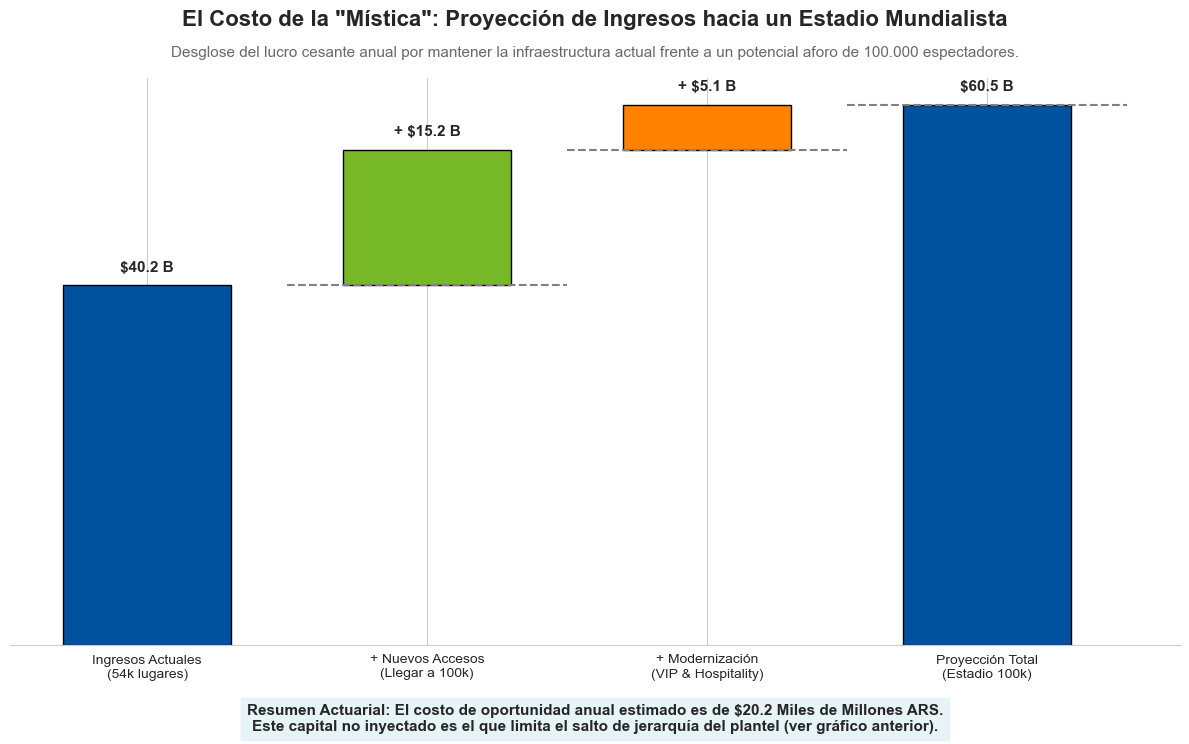

In [12]:
# ==============================================================================
# FASE 9: VISUALIZACIÓN DE NEGOCIO 2 - EL COSTO DE LA "MÍSTICA" (WATERFALL)
# ==============================================================================


actual = ingreso_matchday_hoy
ganancia_total_100k = ganancia_extra
plus_aforo = ganancia_total_100k * 0.75  
plus_hospitality = ganancia_total_100k * 0.25  
potencial = actual + plus_aforo + plus_hospitality

etiquetas = ['Ingresos Actuales\n(54k lugares)', '+ Nuevos Accesos\n(Llegar a 100k)', '+ Modernización\n(VIP & Hospitality)', 'Proyección Total\n(Estadio 100k)']
valores = [actual, plus_aforo, plus_hospitality, potencial]
bases = [0, actual, actual + plus_aforo, 0]
colores = ['#00529F', '#77B829', '#FF8200', '#00529F']

fig, ax = plt.subplots(figsize=(12, 7))
barras = ax.bar(etiquetas, valores, bottom=bases, color=colores, edgecolor='black', width=0.6)

for i in range(1, len(valores)-1):
    ax.plot([i-0.5, i+0.5], [bases[i], bases[i]], color='gray', linestyle='--')
ax.plot([2.5, 3.5], [potencial, potencial], color='gray', linestyle='--')

for i, barra in enumerate(barras):
    alto = barra.get_height()
    base = barra.get_y()
    texto_y = base + alto + (potencial * 0.02) 
    valor_formateado = f"${alto / 1e9:,.1f} B"
    if i in [1, 2]: valor_formateado = f"+ {valor_formateado}"
    ax.text(barra.get_x() + barra.get_width()/2, texto_y, valor_formateado, ha='center', va='bottom', fontweight='bold', fontsize=11)

# Títulos descriptivos
plt.suptitle('El Costo de la "Mística": Proyección de Ingresos hacia un Estadio Mundialista', fontsize=16, fontweight='bold', y=0.98)
plt.title('Desglose del lucro cesante anual por mantener la infraestructura actual frente a un potencial aforo de 100.000 espectadores.', fontsize=11, color='dimgray', pad=15)

# Nota final gerencial
nota_fin = f"Resumen Actuarial: El costo de oportunidad anual estimado es de ${(ganancia_total_100k / 1e9):,.1f} Miles de Millones ARS.\nEste capital no inyectado es el que limita el salto de jerarquía del plantel (ver gráfico anterior)."
plt.figtext(0.5, -0.05, nota_fin, ha="center", fontsize=11, fontweight='bold', bbox={"facecolor":"lightblue", "alpha":0.3, "pad":5})

ax.get_yaxis().set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

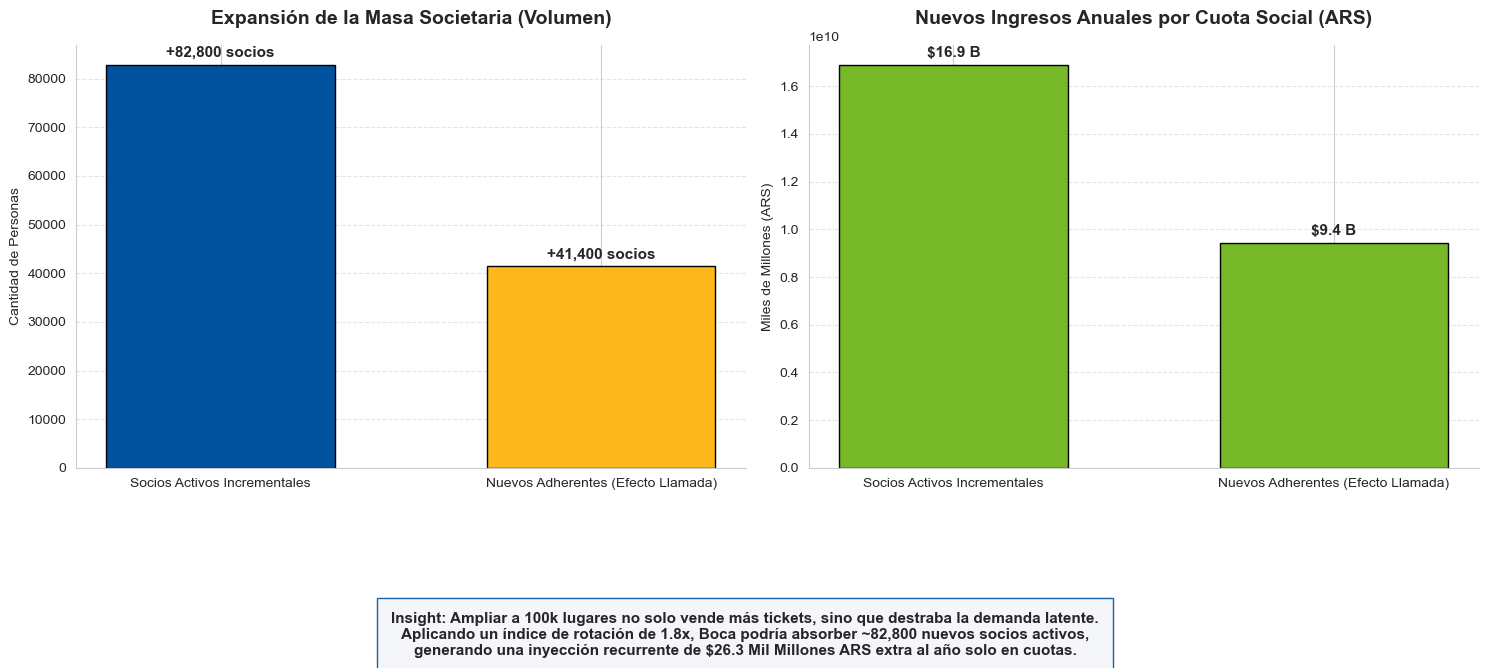

In [13]:
# ==============================================================================
# FASE 10: DEMANDA LATENTE - PROYECCIÓN DE INGRESOS POR CUOTA SOCIAL
# ==============================================================================


# 1. Parámetros del Modelo de Suscripción (Valores reales ARS a Marzo 2026)
cuota_activo_anual = 36000 * 12      # Cuota mensual Activo ($36.000) x 12 meses
cuota_adherente_anual = 19000 * 12   # Cuota mensual Adherente ($19.000) x 12 meses

# 2. Variables de Capacidad
capacidad_actual = 54000
capacidad_nueva = 100000
asientos_nuevos = capacidad_nueva - capacidad_actual

# Índice de Sobrevendidos (Overbooking Rate)
indice_rotacion = 1.8 

# 3. Simulación del Embudo de Conversión
upgrades_a_activos = asientos_nuevos * indice_rotacion
nuevos_adherentes = upgrades_a_activos * 0.5

# 4. Cálculo de Ingresos Incrementales (Delta Anualizado)
delta_upgrades = upgrades_a_activos * (cuota_activo_anual - cuota_adherente_anual)
ingreso_nuevos_adherentes = nuevos_adherentes * cuota_adherente_anual
ingreso_socios_extra_anual = delta_upgrades + ingreso_nuevos_adherentes

# 5. Visualización del Impacto
categorias = ['Socios Activos Incrementales', 'Nuevos Adherentes (Efecto Llamada)']
volumen_personas = [upgrades_a_activos, nuevos_adherentes]
ingresos_generados = [delta_upgrades, ingreso_nuevos_adherentes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Impacto en Volumen
ax1.bar(categorias, volumen_personas, color=['#00529F', '#FFB81C'], edgecolor='black', width=0.6)
ax1.set_title('Expansión de la Masa Societaria (Volumen)', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Cantidad de Personas')
for i, v in enumerate(volumen_personas):
    ax1.text(i, v + (max(volumen_personas)*0.02), f"+{v:,.0f} socios", ha='center', fontweight='bold', fontsize=11)

# Gráfico 2: Impacto en Dinero
ax2.bar(categorias, ingresos_generados, color=['#77B829', '#77B829'], edgecolor='black', width=0.6)
ax2.set_title('Nuevos Ingresos Anuales por Cuota Social (ARS)', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Miles de Millones (ARS)')
for i, v in enumerate(ingresos_generados):
    ax2.text(i, v + (max(ingresos_generados)*0.02), f"${v/1e9:,.1f} B", ha='center', fontweight='bold', fontsize=11)

# Formato estético
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Ajustamos el layout ANTES de poner el texto para reservar el espacio inferior
plt.tight_layout(rect=[0, 0.15, 1, 1])

# Conclusión Actuarial (Movida más abajo con coordenada Y negativa y espacio reservado)
texto_conclusion = (f"Insight: Ampliar a 100k lugares no solo vende más tickets, sino que destraba la demanda latente.\n"
                    f"Aplicando un índice de rotación de {indice_rotacion}x, Boca podría absorber ~{upgrades_a_activos:,.0f} nuevos socios activos,\n"
                    f"generando una inyección recurrente de ${(ingreso_socios_extra_anual/1e9):,.1f} Mil Millones ARS extra al año solo en cuotas.")

# La coordenada Y pasa a -0.10 para separarse de las etiquetas del eje X
plt.figtext(0.5, -0.10, texto_conclusion, ha='center', fontsize=11, fontweight='bold', 
            bbox={"facecolor":"#f4f6f9", "alpha":0.9, "pad":10, "edgecolor":"#00529F"})

plt.show()

In [14]:
# ==============================================================================
# FASE 11: EXPORTACIÓN PARA BUSINESS INTELLIGENCE (POWER BI)
# ==============================================================================
import os

# 1. DEFINICIÓN DE RUTA (Ajustala a tu carpeta real si es distinta)
# Usamos la misma que tenías en los otros notebooks
BASE_PATH = r"C:\Users\Free2\Desktop\Proyecto_Localia_Rendimiento\Datos"

# 2. Parámetros de Negocio (Proyecciones 2026)
PRECIO_TICKET_USD = 45 
GASTO_CONSUMO_USD = 15
INGRESO_TOTAL_POR_PERSONA = PRECIO_TICKET_USD + GASTO_CONSUMO_USD

# Diferencial de Aforo (Capacidad Actual vs. Proyecto 100k)
AFORO_ACTUAL = 54000
AFORO_NUEVO = 100000
BRECHA_CAPACIDAD = AFORO_NUEVO - AFORO_ACTUAL

# 3. Construcción del Dataset de Salida
# Usamos df_final que es el que viene del EDA/Modelado
df_pbi = df_final.copy()

# Calculamos el Lucro Cesante Anual (basado en 25 partidos de local al año)
df_pbi['Lucro_Cesante_Anual_USD'] = (BRECHA_CAPACIDAD * INGRESO_TOTAL_POR_PERSONA * 25)

# Agregamos la Probabilidad del Modelo (Asegurate que 'model' y 'X' estén cargados)
df_pbi['Probabilidad_Victoria'] = model.predict_proba(X)[:, 1]

# 4. Mapeo de nombres para reporte ejecutivo
mapeo_ejecutivo = {
    'Dif_Valor_Plantel': 'Diferencia Valor Mercado',
    'Dif_Ingresos': 'Brecha Ingresos Operativos',
    'Capacidad_Wiki': 'Aforo Actual Estadio',
    'Relacion_Capacidad_Asistencia': 'Porcentaje Ocupación',
    'Victoria_Local': 'Resultado Efectivo (0/1)'
}
df_pbi = df_pbi.rename(columns=mapeo_ejecutivo)

# 5. Exportación Física a la carpeta 'processed'
ruta_final_pbi = os.path.join(BASE_PATH, "processed", "dataset_master_powerbi.csv")

# Nos aseguramos de que la carpeta exista
os.makedirs(os.path.dirname(ruta_final_pbi), exist_ok=True)

df_pbi.to_csv(ruta_final_pbi, index=False, encoding='utf-8-sig')

print(f"📊 FASE 11 FINALIZADA: Dataset consolidado para Power BI.")
print(f"✅ Registros procesados: {len(df_pbi)}")
print(f"📁 Ubicación: {ruta_final_pbi}")

display(df_pbi.head())

📊 FASE 11 FINALIZADA: Dataset consolidado para Power BI.
✅ Registros procesados: 3796
📁 Ubicación: C:\Users\Free2\Desktop\Proyecto_Localia_Rendimiento\Datos\processed\dataset_master_powerbi.csv


,Temporada,Date,Local,Visitante,Goles_Local,Goles_Visitante,Resultado_Texto,Resultado_Num,Attendance,Venue,...,V_IPI,Porcentaje Ocupación,Diferencia Valor Mercado,Brecha Ingresos Operativos,Dif_Popularidad_IPI,Dif_Socios,Capacidad_Estadio,Resultado Efectivo (0/1),Lucro_Cesante_Anual_USD,Probabilidad_Victoria
0,2016,2016-02-05,Huracan,Atletico de Rafaela,0.0,1.0,Derrota,-1.0,0,Estadio Tomás Adolfo Ducó,...,0.00000,0.0,-87.37,0.0,0.008675,0.0,48314.0,0,69000000,0.592000
1,2016,2016-02-05,Banfield,Gimnasia y Esgrima La Plata,2.0,0.0,Victoria,1.0,0,Estadio Florencio Solá,...,0.01012,0.0,-8.12,-14586476.0,-0.007229,0.0,21820.0,1,69000000,0.877500
2,2016,2016-02-06,Argentinos Juniors,Tigre,1.0,1.0,Empate,0.0,0,Estadio Diego Armando Maradona,...,0.00000,0.0,6.25,14570391.0,0.000000,0.0,22063.0,0,69000000,0.257500
3,2016,2016-02-06,Aldosivi,Olimpo,3.0,0.0,Victoria,1.0,0,Estadio José María Minella,...,0.00000,0.0,8.12,0.0,0.000000,0.0,35180.0,1,69000000,0.531333
4,2016,2016-02-06,Patronato,San Lorenzo de Almagro,2.0,2.0,Empate,0.0,0,Estadio Presbítero Bartolomé Grella,...,0.05494,0.0,-38.68,0.0,-0.054940,0.0,22000.0,0,69000000,0.020000
